# L2 · 강도감소계수 $\phi$ 는 왜 상수가 아닌가

## 이 시간에 답할 질문

1. $\phi$ 를 표에서 찾는 숫자로 외우는데, 실은 무엇의 함수인가?
2. 왜 압축지배단면은 $\phi = 0.65$ 로 **벌점**을 받는가?
3. P-M 상관도에서 설계 곡선은 왜 공칭 곡선과 **평행하지 않은가**?
4. 나선철근 기둥은 왜 $\phi$ 와 $\alpha$ 를 모두 우대받는가?

## 필요한 배경

변형률 적합조건, 등가직사각형 응력블록([L1](L1_등가응력블록.ipynb)),
P-M 상관도의 개념.

## 근거 조문

| 내용 | 조문 |
|---|---|
| 강도감소계수 $\phi$ 의 값과 변화구간 보간 | KDS 14 20 10 4.3.3(2) |
| 압축지배변형률한계 $\varepsilon_y$ | KDS 14 20 20 4.1.2(3) |
| 인장지배변형률한계 $\varepsilon_{t,tl}$ | KDS 14 20 20 4.1.2(4) |
| 최대 설계 축강도 $\alpha\phi P_o$ | KDS 14 20 20 식 (4.1-16), (4.1-17) |

:::{tip}
같은 내용을 슬라이더로 움직여 보려면
[대화형 탐색기](../_static/explorer.html)를 연다. 값을 바꾸면 그래프가 바로
따라 바뀐다.
:::

## 0. 준비

**아래 코드가 하는 일** — 한글 글꼴을 등록하고 단면 분류 색을 정한다.

In [1]:
%matplotlib inline

import glob
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager


def use_korean_font():
    """설치된 한글 글꼴을 찾아 matplotlib 에 등록한다."""
    site = Path(sys.prefix, "lib", f"python{sys.version_info.major}.{sys.version_info.minor}", "site-packages")
    for pattern in (
        str(site / "koreanize_matplotlib/fonts/*.ttf"),
        "/usr/share/fonts/**/*Nanum*.ttf",
        "/usr/share/fonts/**/*NotoSansCJK*.ot[fc]",
        "/usr/share/fonts/**/*NotoSansKR*.otf",
    ):
        for path in glob.glob(pattern, recursive=True):
            font_manager.fontManager.addfont(path)

    installed = {f.name for f in font_manager.fontManager.ttflist}
    for name in ("NanumGothic", "Malgun Gothic", "AppleGothic",
                 "Noto Sans CJK KR", "Noto Sans KR", "WenQuanYi Zen Hei"):
        if name in installed:
            plt.rcParams["font.family"] = name
            return name

    warnings.warn(
        "한글 글꼴을 찾지 못했다. 그림의 한글이 깨진다면 "
        "`pip install koreanize-matplotlib` 로 글꼴만 내려받거나, "
        "나눔고딕·Noto Sans KR 을 시스템에 설치한다.",
        stacklevel=2,
    )
    return None


print("사용 글꼴:", use_korean_font())

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# 단면 분류에 쓰는 색 (압축지배 · 변화구간 · 인장지배)
C_COMP, C_TRAN, C_TENS = "#ad3327", "#b5811f", "#2a7355"
BAND = {"압축지배단면": C_COMP, "변화구간단면": C_TRAN, "인장지배단면": C_TENS}

사용 글꼴: NanumGothic


## 1. 단면 하나로 시작한다

**아래 코드가 하는 일** — 이 노트북에서 쓸 보와 기둥을 만드는 함수를
정의한다. 기둥은 500 × 500, 8-D22, 피복 50 mm, $f_{ck}$ 27 MPa,
SD400 이다.

In [2]:
from concreteproperties import ConcreteSection
from sectionproperties.pre.library import concrete_rectangular_section

from concreteproperties_kds import KDS


def beam(fck=27, fy=400, n_bar=4, d=600, b=400, cover=50, profile="block"):
    """단철근 직사각형 보. 압축철근이 없어 손계산과 조건이 정확히 같다."""
    kds = KDS()
    conc = kds.create_concrete_material(
        compressive_strength=fck, ultimate_profile=profile
    )
    steel = kds.create_steel_material(yield_strength=fy)

    geom = concrete_rectangular_section(
        d=d, b=b,
        dia_top=22, area_top=387.1, n_top=0, c_top=cover,
        dia_bot=22, area_bot=387.1, n_bot=n_bar, c_bot=cover,
        n_circle=16, conc_mat=conc, steel_mat=steel,
    )
    kds.assign_concrete_section(ConcreteSection(geom))
    return kds


def column(fck=27, fy=400, column_type="tie", profile="block"):
    """500 x 500 기둥 (8-D22, 피복 50 mm)."""
    kds = KDS(column_type=column_type)
    conc = kds.create_concrete_material(
        compressive_strength=fck, ultimate_profile=profile
    )
    steel = kds.create_steel_material(yield_strength=fy)

    geom = concrete_rectangular_section(
        d=500, b=500,
        dia_top=22, area_top=387.1, n_top=3, c_top=50,
        dia_bot=22, area_bot=387.1, n_bot=3, c_bot=50,
        dia_side=22, area_side=387.1, n_side=1, c_side=50,
        n_circle=16, conc_mat=conc, steel_mat=steel,
    )
    kds.assign_concrete_section(ConcreteSection(geom))
    return kds


def depth(kds):
    """단면 상단에서 최하단 철근 도심까지의 유효깊이 d."""
    sec = kds.concrete_section
    top = sec.compound_geometry.geom.bounds[3]
    return top - min(g.calculate_centroid()[1] for g in sec.reinf_geometries_lumped)


print("보와 기둥을 만드는 함수를 정의했다.")

보와 기둥을 만드는 함수를 정의했다.


**아래 코드가 하는 일** — 기둥을 만들고 KDS 가 정한 두 변형률 한계와
강도감소계수의 양 끝값을 출력한다.

SD400 이므로 $\varepsilon_y = f_y/E_s = 400/200{,}000 = 0.002$ 이고,
인장지배한계는 $\max(0.005,\ 2.5\varepsilon_y) = 0.005$ 다.

압축지배변형률한계  εy   = 0.00200   (= fy / 200,000)
인장지배변형률한계  εt,tl = 0.00500   (= max(0.005, 2.5·εy))
압축지배단면의 φ          = 0.65   (띠철근)
인장지배단면의 φ          = 0.85
최대 축강도 저감계수 α     = 0.80


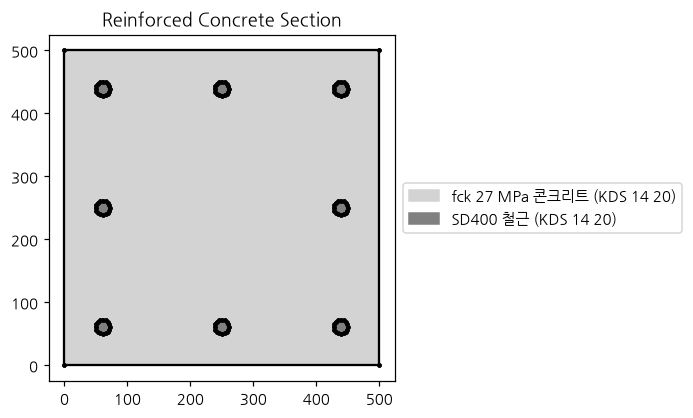

<Axes: title={'center': 'Reinforced Concrete Section'}>

In [3]:
kds = column()
conc_sec = kds.concrete_section

print(f"압축지배변형률한계  εy   = {kds.eps_y:.5f}   (= fy / 200,000)")
print(f"인장지배변형률한계  εt,tl = {kds.eps_tl:.5f}   (= max(0.005, 2.5·εy))")
print(f"압축지배단면의 φ          = {kds.phi_comp:.2f}   (띠철근)")
print(f"인장지배단면의 φ          = 0.85")
print(f"최대 축강도 저감계수 α     = {kds.alpha_max:.2f}")

conc_sec.plot_section()

## 2. $\phi$ 는 무엇의 함수인가

먼저 답부터 보자. $\phi$ 는 **최외단 인장철근의 순인장변형률
$\varepsilon_t$ 의 함수**다. 축력이나 단면 크기의 함수가 아니다.

$$
\phi(\varepsilon_t) =
\begin{cases}
0.65 & \varepsilon_t \le \varepsilon_y \quad \text{(압축지배)} \\[4pt]
0.65 + 0.20\,\dfrac{\varepsilon_t - \varepsilon_y}{\varepsilon_{t,tl} - \varepsilon_y}
      & \varepsilon_y < \varepsilon_t < \varepsilon_{t,tl} \quad \text{(변화구간)} \\[8pt]
0.85 & \varepsilon_t \ge \varepsilon_{t,tl} \quad \text{(인장지배)}
\end{cases}
$$

**아래 코드가 하는 일** — $\varepsilon_t$ 를 0 부터 0.01 까지 훑으며
$\phi$ 를 계산해 곡선으로 그린다. 세 구간을 색으로 칠하고, 경계에
$\varepsilon_y$ 와 $\varepsilon_{t,tl}$ 를 표시한다.

**볼 것** — $\phi$ 가 계단이 아니라 **경사로**라는 점.

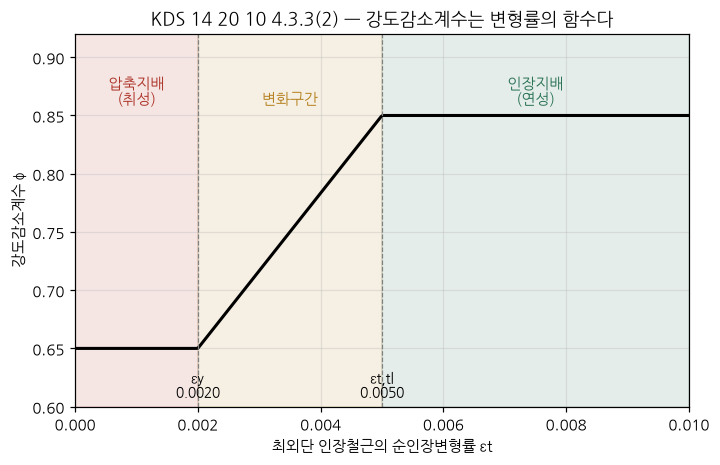

In [4]:
eps = np.linspace(0.0, 0.010, 400)
phi = np.array([kds.capacity_reduction_factor(e) for e in eps])

fig, ax = plt.subplots(figsize=(7.2, 4.4))

ax.axvspan(0, kds.eps_y, color=C_COMP, alpha=0.12)
ax.axvspan(kds.eps_y, kds.eps_tl, color=C_TRAN, alpha=0.12)
ax.axvspan(kds.eps_tl, eps[-1], color=C_TENS, alpha=0.12)

ax.plot(eps, phi, color="k", lw=2)

for x, label in [(kds.eps_y, "εy"), (kds.eps_tl, "εt,tl")]:
    ax.axvline(x, color="grey", ls="--", lw=0.8)
    ax.annotate(f"{label}\n{x:.4f}", xy=(x, 0.606),
                ha="center", va="bottom", fontsize=9)

ax.text(kds.eps_y / 2, 0.86, "압축지배\n(취성)", ha="center", color=C_COMP)
ax.text((kds.eps_y + kds.eps_tl) / 2, 0.86, "변화구간", ha="center", color=C_TRAN)
ax.text((kds.eps_tl + eps[-1]) / 2, 0.86, "인장지배\n(연성)", ha="center", color=C_TENS)

ax.set_xlabel("최외단 인장철근의 순인장변형률 εt")
ax.set_ylabel("강도감소계수 φ")
ax.set_title("KDS 14 20 10 4.3.3(2) — 강도감소계수는 변형률의 함수다")
ax.set_ylim(0.60, 0.92)
ax.set_xlim(0, eps[-1])
plt.show()

**여기서 알 것.** 표에 적힌 0.65 와 0.85 는 이 함수의 **양 끝값**일
뿐이다. 실제 기둥은 대부분 그 사이 어딘가에 있다.

"압축지배단면은 $\phi = 0.65$" 만 외운 학생은 변화구간에 있는 기둥에서
$\phi$ 를 0.65 로 잡아 강도를 과소평가하거나, 반대로 0.85 로 잡아
**위험측 설계**를 하게 된다.

## 3. 설계의 의도 — 왜 취성 파괴에 벌점을 주는가

$\phi$ 는 "재료가 약할까 봐" 곱하는 계수가 아니다. 그건 재료계수의
역할이고(KDS 14 20 20 부록이 재료계수 방식을 따로 규정한다), KDS 본문의
$\phi$ 에는 **파괴 양상에 대한 벌점**이 섞여 있다.

- **인장지배**($\varepsilon_t \ge 0.005$) — 철근이 충분히 항복한 뒤
  콘크리트가 압괴한다. 처짐과 균열로 미리 경고가 오고, 파괴까지 변형
  여유가 크다. 사람이 대피할 시간이 있고, 부재가 힘을 옆으로 넘겨줄
  기회도 있다. → $\phi = 0.85$
- **압축지배**($\varepsilon_t \le \varepsilon_y$) — 철근이 항복하기
  전에 콘크리트가 먼저 깨진다. 경고 없이 갑자기 무너진다. → $\phi = 0.65$

같은 공칭강도라도 **경고 없이 무너지는 단면은 더 큰 안전여유를
요구한다**는 뜻이다. 이것이 강도설계법의 핵심 사고다. 안전율을 재료와
하중에만 걸지 않고, **파괴의 성격**에도 건다.

변화구간을 둔 까닭도 같은 맥락이다. 파괴 양상은 경계에서 뚝 바뀌지 않고
서서히 옮겨 간다. $\phi$ 가 계단이면 $\varepsilon_t$ 가 0.0049 인 단면과
0.0051 인 단면의 설계강도가 30 % 나 벌어져, 물리적 근거가 없는 불연속이
생긴다.

## 4. 단면 위에서 확인하기

**아래 코드가 하는 일** — 축력을 인장에서 압축까지 훑으면서, 각 축력에서
중립축 깊이 $d_n$, 순인장변형률 $\varepsilon_t$, 단면 분류, $\phi$,
설계휨강도를 한 줄씩 출력한다.

`ultimate_bending_capacity(n_design=...)` 는 주어진 축력에서 극한상태를
푼다. $\phi$ 가 $\varepsilon_t$ 에 의존하고 $\varepsilon_t$ 는 다시
$N_u = N_d/\phi$ 에 의존하므로, 내부에서 비선형 해를 구한다.

**볼 것** — 축력이 커질수록 중립축이 깊어져 $\varepsilon_t$ 가 줄고,
어느 지점에서 인장지배 → 변화구간 → 압축지배로 넘어간다.

In [5]:
rows = []
for n_d in [-800, -400, 0, 300, 600, 900, 1200, 1600, 2000, 2600, 3200]:
    f_res, u_res, phi_i = kds.ultimate_bending_capacity(n_design=n_d * 1e3)
    e_t = kds.net_tensile_strain(theta=0, d_n=u_res.d_n)
    rows.append((n_d, u_res.d_n, e_t, kds.section_classification(e_t),
                 phi_i, f_res.m_x / 1e6))

print(f"{'Nd(kN)':>8} {'중립축 dn(mm)':>13} {'εt':>9} {'단면 분류':>12}"
      f" {'φ':>6} {'φMn(kNm)':>11}")
print("-" * 66)
for n_d, d_n, e_t, cls, phi_i, m in rows:
    e_str = "    inf" if e_t == float("inf") else f"{e_t:7.5f}"
    print(f"{n_d:8.0f} {d_n:13.1f} {e_str:>9} {cls:>12} {phi_i:6.3f} {m:11.1f}")

  Nd(kN)    중립축 dn(mm)        εt        단면 분류      φ    φMn(kNm)
------------------------------------------------------------------
    -800           0.0       inf       인장지배단면  0.850        52.1
    -400           0.0       inf       인장지배단면  0.850       134.6
       0          72.3   0.01675       인장지배단면  0.850       217.0
     300          95.5   0.01187       인장지배단면  0.850       272.7
     600         122.3   0.00855       인장지배단면  0.850       323.9
     900         152.5   0.00620       인장지배단면  0.850       369.1
    1200         181.7   0.00467       변화구간단면  0.828       386.2
    1600         262.5   0.00222       변화구간단면  0.665       345.6
    2000         311.5   0.00135       압축지배단면  0.650       325.4
    2600         382.9   0.00048       압축지배단면  0.650       288.9
    3200         461.0  -0.00016       압축지배단면  0.650       229.7


## 5. P-M 상관도 위에 칠해 보기

**아래 코드가 하는 일** — 상관도를 48 점으로 생성하고, 각 점의
$\varepsilon_t$ 를 구해 단면 분류에 따라 색을 입힌다.
`moment_interaction_diagram` 은 (설계 상관도, 공칭 상관도, φ 목록)
세 가지를 함께 돌려준다.

**볼 것** — 상관도의 **아래쪽(인장측)은 초록, 위쪽(압축측)은 빨강**이다.
축력이 클수록 취성 파괴에 가까워진다는 사실이 곡선 하나에 담긴다.
빨강과 노랑이 만나는 곳이 대략 균형점이다.

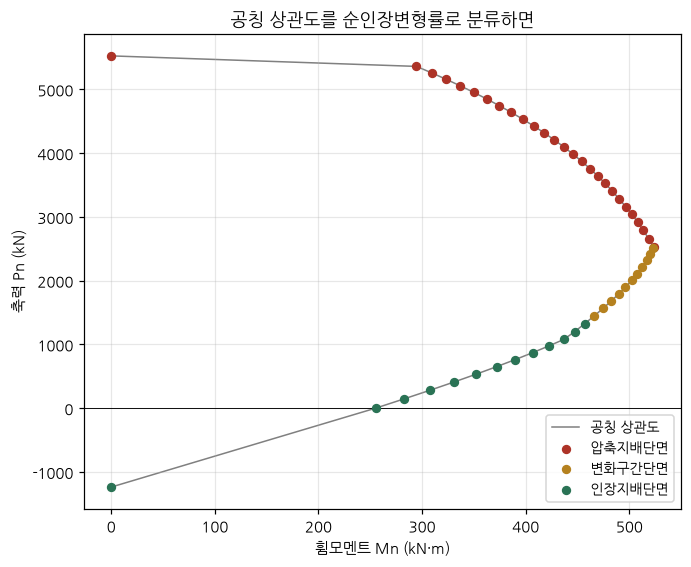

In [6]:
f_mi, mi, phis = kds.moment_interaction_diagram(n_points=48, progress_bar=False)

n_nom = np.array([r.n for r in mi.results]) / 1e3
m_nom = np.array([r.m_x for r in mi.results]) / 1e6
n_des = np.array([r.n for r in f_mi.results]) / 1e3
m_des = np.array([r.m_x for r in f_mi.results]) / 1e6

eps_t = np.array([kds.net_tensile_strain(theta=0, d_n=r.d_n) for r in mi.results])
cls = [kds.section_classification(e) for e in eps_t]

fig, ax = plt.subplots(figsize=(7.0, 5.6))
ax.plot(m_nom, n_nom, color="grey", lw=1.0, zorder=1, label="공칭 상관도")
for name, colour in BAND.items():
    sel = [i for i, c in enumerate(cls) if c == name]
    ax.scatter(m_nom[sel], n_nom[sel], s=26, color=colour, zorder=3, label=name)

ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("휨모멘트 Mn (kN·m)")
ax.set_ylabel("축력 Pn (kN)")
ax.set_title("공칭 상관도를 순인장변형률로 분류하면")
ax.legend(loc="lower right", fontsize=9)
plt.show()

## 6. 상관도를 따라 $\phi$ 가 어떻게 변하는가

**아래 코드가 하는 일** — 같은 상관도의 각 점에서 $\phi$ 만 뽑아 축력에
대해 그린다.

**볼 것** — 2절의 $\phi(\varepsilon_t)$ 곡선과 **같은 모양이 좌우로
뒤집혀** 나타난다. 축력이 커질수록 $\varepsilon_t$ 가 줄기 때문이다.

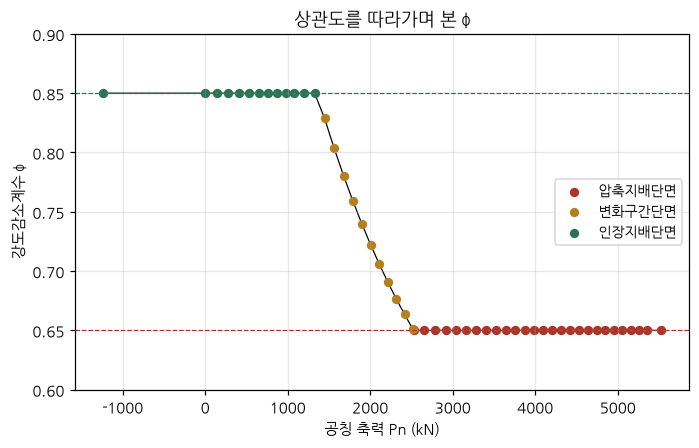

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))

phis_arr = np.array(phis)
for name, colour in BAND.items():
    sel = [i for i, c in enumerate(cls) if c == name]
    ax.scatter(n_nom[sel], phis_arr[sel], s=26, color=colour, label=name)

ax.plot(n_nom, phis_arr, color="k", lw=0.8, zorder=0)
ax.axhline(0.85, color=C_TENS, ls="--", lw=0.8)
ax.axhline(kds.phi_comp, color=C_COMP, ls="--", lw=0.8)
ax.set_xlabel("공칭 축력 Pn (kN)")
ax.set_ylabel("강도감소계수 φ")
ax.set_title("상관도를 따라가며 본 φ")
ax.set_ylim(0.60, 0.90)
ax.legend(fontsize=9)
plt.show()

## 7. 설계 곡선은 왜 공칭 곡선과 평행하지 않은가

여기가 이 시간의 핵심이다. 설계 상관도는 공칭 상관도에 **일정한 수를
곱한 것이 아니다.** 점마다 다른 $\phi$ 가 곱해진다.

게다가 압축측은 최대 설계 축강도 $\alpha\phi P_o$ 에서 **잘린다**
(KDS 14 20 20 식 (4.1-16), (4.1-17)). 띠철근 $\alpha = 0.80$,
나선철근 $0.85$ 다.

**왜 이 상한이 따로 필요한가.** $\phi$ 는 파괴 양상에 대한 벌점이지,
**편심에 대한 보험이 아니다.** 순수압축으로 설계한 기둥이라도 시공
오차, 하중의 우발적 편심, 기둥의 초기 휨 때문에 실제로는 약간의 모멘트를
받는다. 상관도 꼭짓점 근처는 기울기가 매우 가팔라서, 작은 모멘트가
생기면 축강도가 급격히 떨어진다. 그래서 기준은 아예 그 영역을 쓰지 못하게
잘라 놓았다. 이것이 $\alpha$ 의 정체다 — 최소 편심을 강제하는 장치다.

**아래 코드가 하는 일** — 공칭과 설계 상관도를 겹쳐 그리고, 같은 축력
지점을 점선으로 이어 간격을 보인다. 최대 설계 축강도를 가로 파선으로
표시한다.

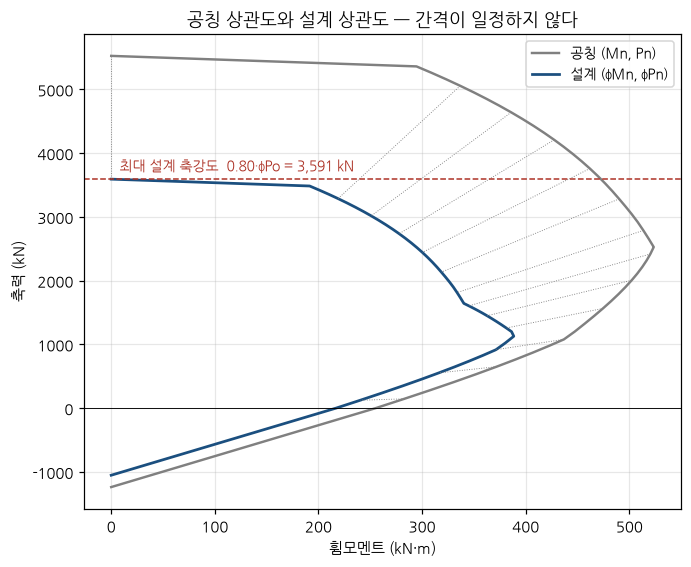

In [8]:
n_max_nom, n_max_des = kds.max_axial_strength()

fig, ax = plt.subplots(figsize=(7.0, 5.6))
ax.plot(m_nom, n_nom, color="grey", lw=1.6, label="공칭 (Mn, Pn)")
ax.plot(m_des, n_des, color="#1b4f7f", lw=1.8, label="설계 (φMn, φPn)")

for i in range(0, len(m_nom), 4):
    ax.plot([m_nom[i], m_des[i]], [n_nom[i], n_des[i]],
            color="grey", lw=0.6, ls=":")

ax.axhline(n_max_des / 1e3, color=C_COMP, ls="--", lw=1.0)
ax.annotate(f"최대 설계 축강도  {kds.alpha_max:.2f}·φPo = {n_max_des / 1e3:,.0f} kN",
            xy=(8, n_max_des / 1e3 + 90), fontsize=9,
            ha="left", va="bottom", color=C_COMP)

ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("휨모멘트 (kN·m)")
ax.set_ylabel("축력 (kN)")
ax.set_title("공칭 상관도와 설계 상관도 — 간격이 일정하지 않다")
ax.legend(loc="upper right", fontsize=9)
plt.show()

**아래 코드가 하는 일** — 두 곡선의 **비**를 그린다. 그 비가 곧
$\phi$ 임을 확인한다.

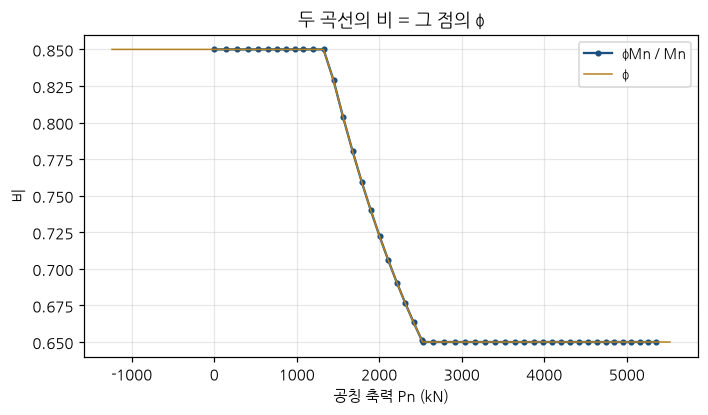

In [9]:
with np.errstate(divide="ignore", invalid="ignore"):
    ratio = np.where(np.abs(m_nom) > 1e-6, m_des / m_nom, np.nan)

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.plot(n_nom, ratio, "o-", ms=3, color="#1b4f7f", label="φMn / Mn")
ax.plot(n_nom, phis_arr, lw=1.0, color=C_TRAN, label="φ")
ax.set_xlabel("공칭 축력 Pn (kN)")
ax.set_ylabel("비")
ax.set_title("두 곡선의 비 = 그 점의 φ")
ax.legend(fontsize=9)
plt.show()

## 8. 띠철근과 나선철근

| | 띠철근 | 나선철근 |
|---|---|---|
| 압축지배단면의 $\phi$ | 0.65 | **0.70** |
| 최대 축강도 계수 $\alpha$ | 0.80 | **0.85** |

**왜 우대하는가.** 나선철근은 심부 콘크리트를 **원주 방향으로 구속**한다.
피복이 떨어져 나간 뒤에도 심부가 삼축응력 상태에 놓여 축력을 유지하며
변형을 이어 간다. 즉 압축파괴가 덜 급작스럽다 — 3절에서 말한 "경고"가
생긴다. $\phi$ 가 파괴 양상에 대한 벌점이므로, 양상이 나아지면 벌점도
줄어드는 것이 일관된다.

띠철근은 모서리에서만 구속이 걸려서 같은 효과를 내지 못한다. 나선철근의
우대를 받으려면 KDS 14 20 50 의 나선철근 상세 규정(간격, 철근비, 겹침)을
만족해야 한다.

**아래 코드가 하는 일** — 같은 단면을 띠철근과 나선철근으로 각각 풀어
설계 상관도를 겹쳐 그리고, 몇 개 지점의 값을 표로 비교한다.

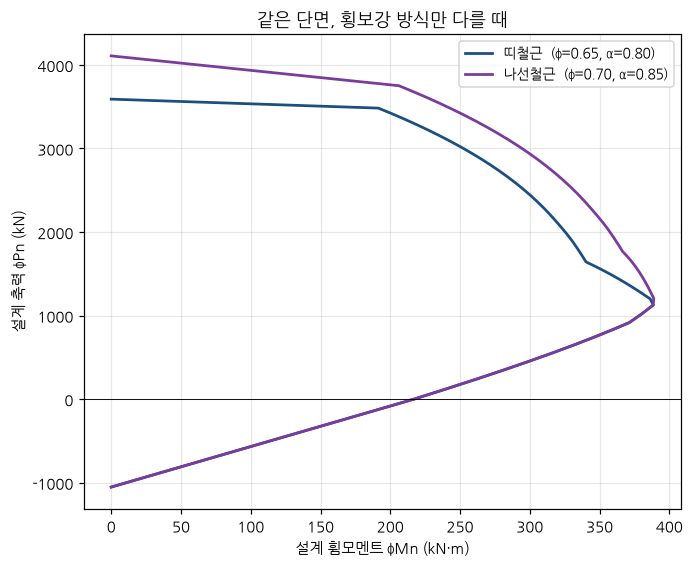

In [10]:
kds_s = column(column_type="spiral")
f_mi_s, _, _ = kds_s.moment_interaction_diagram(n_points=48, progress_bar=False)

m_s = np.array([r.m_x for r in f_mi_s.results]) / 1e6
n_s = np.array([r.n for r in f_mi_s.results]) / 1e3

fig, ax = plt.subplots(figsize=(7.0, 5.6))
ax.plot(m_des, n_des, lw=1.8, color="#1b4f7f", label="띠철근  (φ=0.65, α=0.80)")
ax.plot(m_s, n_s, lw=1.8, color="#7a3b9c", label="나선철근  (φ=0.70, α=0.85)")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("설계 휨모멘트 φMn (kN·m)")
ax.set_ylabel("설계 축력 φPn (kN)")
ax.set_title("같은 단면, 횡보강 방식만 다를 때")
ax.legend(loc="upper right", fontsize=9)
plt.show()

In [11]:
_, n_max_t = kds.max_axial_strength()
_, n_max_s = kds_s.max_axial_strength()

print(f"{'':16}{'띠철근':>13}{'나선철근':>13}{'차이':>9}")
print("-" * 52)
print(f"{'최대 설계 축강도':16}{n_max_t / 1e3:10,.0f} kN"
      f"{n_max_s / 1e3:10,.0f} kN{(n_max_s / n_max_t - 1) * 100:8.1f} %")

for n_d in [1500, 2500]:
    m_t = kds.ultimate_bending_capacity(n_design=n_d * 1e3)[0].m_x / 1e6
    m_sp = kds_s.ultimate_bending_capacity(n_design=n_d * 1e3)[0].m_x / 1e6
    print(f"{f'φMn @ {n_d} kN':16}{m_t:9,.1f} kN·m{m_sp:9,.1f} kN·m"
          f"{(m_sp / m_t - 1) * 100:8.1f} %")

                          띠철근         나선철근       차이
----------------------------------------------------
최대 설계 축강도            3,591 kN     4,109 kN    14.4 %


φMn @ 1500 kN       357.2 kN·m    379.3 kN·m     6.2 %


φMn @ 2500 kN       296.2 kN·m    331.7 kN·m    12.0 %


**볼 것** — 나선철근 상관도가 압축측에서 바깥으로 밀려난다. 휨이
지배하는 아래쪽에서는 두 곡선이 겹친다. 그쪽은 어차피 $\phi = 0.85$ 로
같기 때문이다. **우대는 취성 파괴 영역에서만 주어진다.**

## 9. 직접 바꿔 보기

**아래 코드가 하는 일** — 철근 항복강도를 바꿔 $\varepsilon_y$ 와
$\varepsilon_{t,tl}$ 이 어떻게 움직이는지, 그래서 변화구간이 어떻게
넓어지는지 본다.

fy = 600 MPa,  fck = 27 MPa
  εy    = 0.00300   (= fy / 200,000)
  εt,tl = 0.00750   (= max(0.005, 2.5·εy))
  변화구간 폭 = 0.00450   (SD400 기준 0.00300)


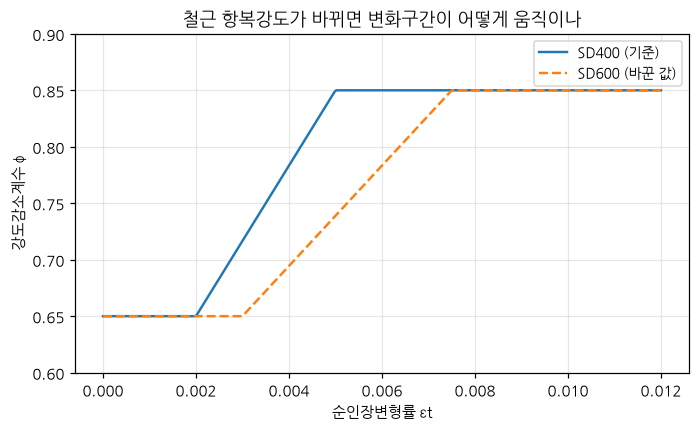

In [12]:
fy = 600     # ← 400, 500, 600 으로 바꿔 보라
fck = 27     # ← 27, 40, 60 으로 바꿔 보라

kds_x = column(fck=fck, fy=fy)

print(f"fy = {fy} MPa,  fck = {fck} MPa")
print(f"  εy    = {kds_x.eps_y:.5f}   (= fy / 200,000)")
print(f"  εt,tl = {kds_x.eps_tl:.5f}   (= max(0.005, 2.5·εy))")
print(f"  변화구간 폭 = {kds_x.eps_tl - kds_x.eps_y:.5f}"
      f"   (SD400 기준 {kds.eps_tl - kds.eps_y:.5f})")

eps_x = np.linspace(0, 0.012, 300)
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.plot(eps_x, [kds.capacity_reduction_factor(e) for e in eps_x],
        lw=1.6, label="SD400 (기준)")
ax.plot(eps_x, [kds_x.capacity_reduction_factor(e) for e in eps_x],
        lw=1.6, ls="--", label=f"SD{fy} (바꾼 값)")
ax.set_xlabel("순인장변형률 εt")
ax.set_ylabel("강도감소계수 φ")
ax.set_title("철근 항복강도가 바뀌면 변화구간이 어떻게 움직이나")
ax.set_ylim(0.60, 0.90)
ax.legend(fontsize=9)
plt.show()

## 10. 생각해 볼 문제

1. **SD600 을 쓰면 왜 인장지배단면을 만들기 어려워지는가?**
   SD600 의 $\varepsilon_y = 0.003$ 이므로 인장지배한계가
   $2.5 \times 0.003 = 0.0075$ 로 올라간다. 같은 단면에서 이 조건을
   만족시키려면 무엇을 바꿔야 하는가? 고강도 철근을 쓰는 이득과 이
   부담을 견줘 보라.

2. **철근비를 늘리면 $\phi M_n$ 은 계속 커지는가?**
   휨부재에서 인장철근을 계속 늘려 보라. 어느 지점부터 $\phi$ 가 떨어지고
   $\phi M_n$ 의 증가가 둔해진다. 그 지점의 물리적 의미는?
   ([L3](L3_설계파라미터.ipynb) 에서 직접 확인한다.)

3. **$\phi$ 를 곱한 뒤에도 압축측 상한 $\alpha\phi P_o$ 가 왜 또
   필요한가?** 7절의 설명을 자기 말로 다시 써 보라. $\phi$ 만으로는
   무엇을 막지 못하는가?

4. **나선철근의 우대를 받으려면 어떤 조건을 만족해야 하는가?**
   KDS 14 20 50 의 나선철근 상세 규정을 찾아보고, 조건을 못 지킨
   나선철근 기둥은 어떻게 취급해야 할지 논하라.

## 정리

- $\phi$ 는 표에서 찾는 상수가 아니라 $\varepsilon_t$ 의 **연속 함수**다.
- 벌점의 근거는 재료의 불확실성이 아니라 **파괴의 예고 여부**다.
- 그래서 설계 상관도는 공칭 상관도와 평행할 수 없다.
- 압축측 절단($\alpha\phi P_o$)은 $\phi$ 와 별개의 장치로, 최소 편심을
  강제한다.
- 나선철근의 우대는 구속 효과로 파괴 양상이 나아진 데 대한 보상이며,
  취성 영역에서만 주어진다.

조문과 구현 함수의 대응은
[설계식 목록](../user_guide/design_codes/equations.md) 에 정리되어 있다.
다음 편은 [L3 · 설계 파라미터](L3_설계파라미터.ipynb) 다.